In [1]:
import pandas as pd
import seaborn.objects as so

In [5]:
df = pd.read_csv("../results/2d/all_participants_summary.csv")
df.head()

,participant,workspace,dimension,parameter,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,p1,1212,x,sigma_prop,8.575,0.224,8.170,9.016,0.003,0.002,7605.0,6847.0,1.0
1,p1,1212,x,action_cost,0.001,0.000,0.001,0.001,0.000,0.000,7028.0,7251.0,1.0
2,p1,1212,x,action_variability,0.198,0.002,0.194,0.202,0.000,0.000,7021.0,7420.0,1.0
3,p2,1212,x,sigma_prop,13.563,0.336,12.965,14.222,0.004,0.003,7095.0,7191.0,1.0
4,p2,1212,x,action_cost,0.001,0.000,0.001,0.001,0.000,0.000,7079.0,6848.0,1.0


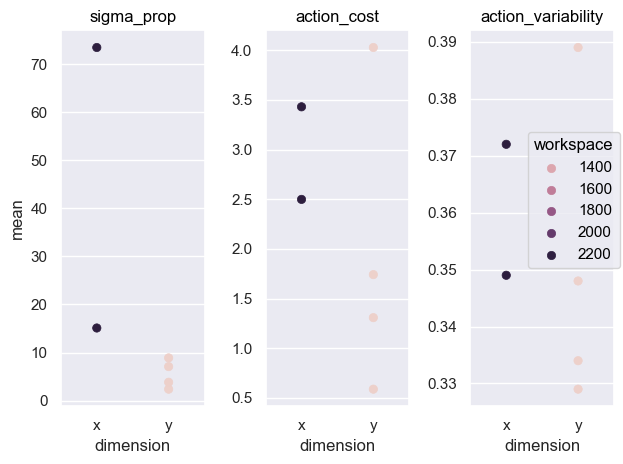

In [11]:
g = (
    so.Plot(df[df['r_hat'] > 1.0], x="dimension", y="mean", color="workspace")
    .add(so.Dot())
    .facet(col="parameter")
    .share(y=False)
)
g.show()

In [18]:
from cppp.models.multisensory import BoundedActorPointMassDynamics

from jax import random, numpy as jnp

from lqg import xcorr
import matplotlib.pyplot as plt

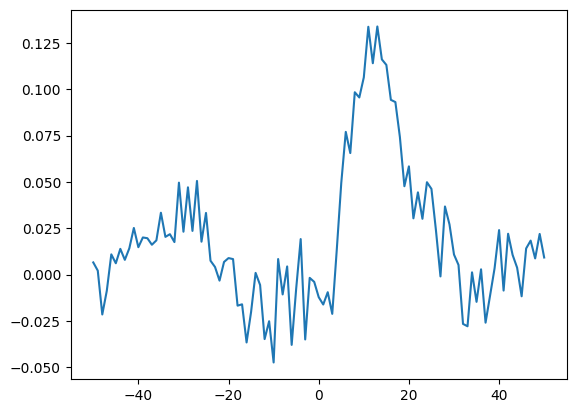

In [23]:
sampling_rate = 18.18

motor_params = {
    "action_variability": 0.3,
    "action_cost": 4.0,
}

model = BoundedActorPointMassDynamics(
        process_noise=1.2,
        sigmas=[10.0],
        delays=[1],
        dt=1 / sampling_rate,
        T=200 - 1,
        **motor_params,
    )

x = model.simulate(n=20, rng_key=random.PRNGKey(0))

vels = jnp.diff(x, axis=-2)

lags, correls = xcorr(vels[:, :, 1], vels[:, :, 0], maxlags=50)

plt.plot(lags, correls.mean(axis=0))